In [38]:
import numpy as np
import os
import json
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy.stats import levene
from itertools import combinations
import sys
sys.path.append('../../..')
from style_setup import set_thesis_style
set_thesis_style()

# Analysis

## Model data

Single-Source:
  Mean: 1.3000
  Median: 1.2684
  Variance: 0.0402
  Standard Deviation: 0.2006

Multi-Source:
  Mean: 1.3198
  Median: 1.2918
  Variance: 0.0403
  Standard Deviation: 0.2007

Human-Source:
  Mean: 1.3179
  Median: 1.2885
  Variance: 0.0407
  Standard Deviation: 0.2017

None (Vanilla):
  Mean: 1.4512
  Median: 1.3336
  Variance: 1.0116
  Standard Deviation: 1.0058



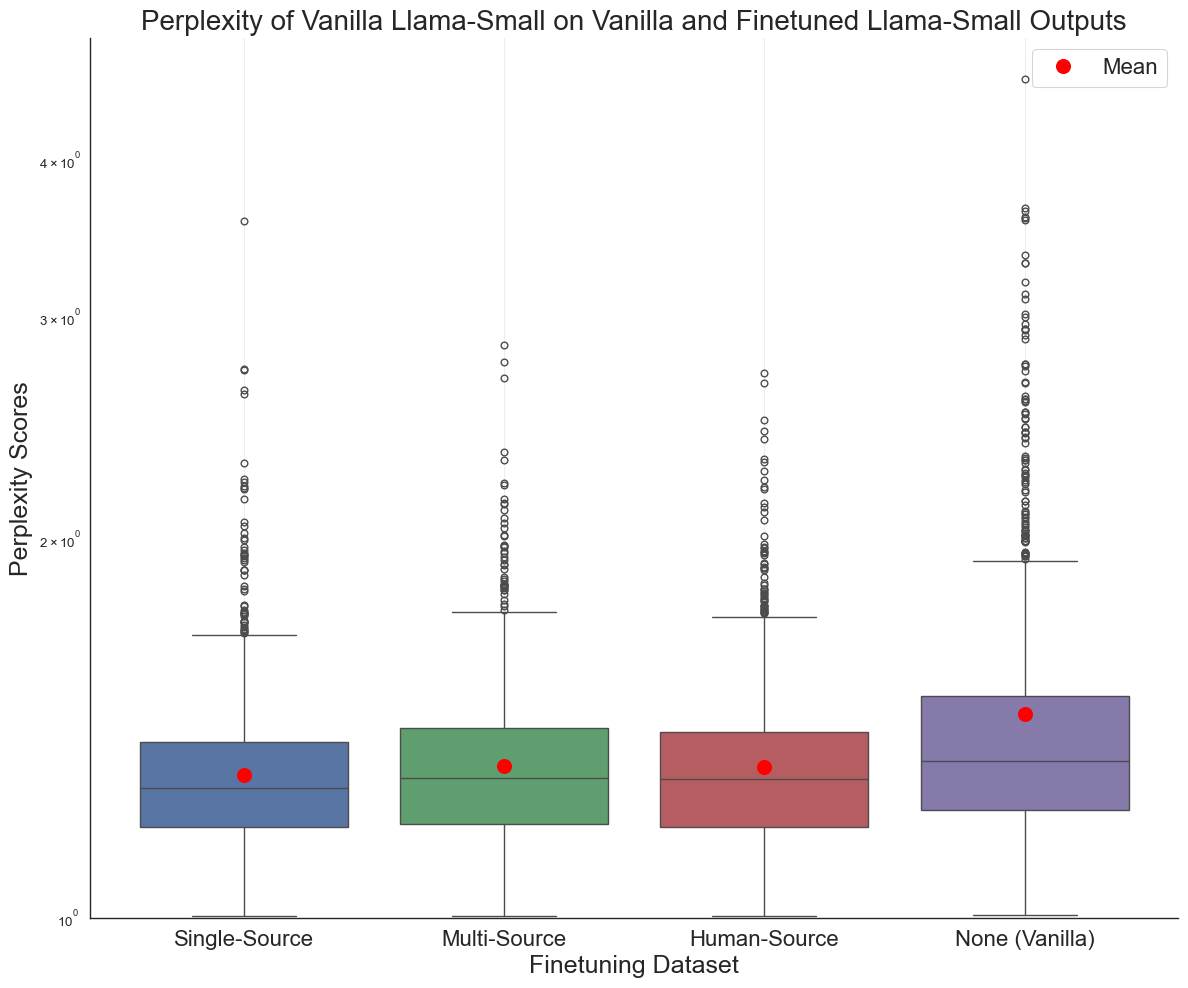

In [41]:
# Get all perplexity files
ppl_files = glob.glob("/Users/maxschaffelder/Desktop/Thesis/Data/exp_1/data/small/ppl/*_ppl.jsonl")

# Define datasets in desired order with their corresponding filenames
datasets = [
    ("Single-Source", "generation_results_lora_llama_8b_single_v8_ppl.jsonl"),
    ("Multi-Source", "generation_results_lora_llama_8b_multi_v3_ppl.jsonl"),
    ("Human-Source", "generation_results_lora_llama_8b_human_v3_ppl.jsonl"),
    ("None (Vanilla)", "dolly_test_Llama_ppl.jsonl")
]

# Create set of target filenames for quick lookup
target_files = {filename for _, filename in datasets}

# Extract perplexity values
perplexities_by_file = {}
for file in ppl_files:
    file_name = os.path.basename(file)
    if file_name in target_files:
        perplexities_by_file[file_name] = []
        with open(file, 'r') as f:
            for line in f:
                data = json.loads(line)
                perp = data["token_probabilities_Llama-3.1-8B-Instruct"]["perplexity"]
                perplexities_by_file[file_name].append(perp)

# Prepare data for plotting
boxplot_data = []
boxplot_labels = []
mean_perplexities = {}

for dataset_name, file_name in datasets:
    if file_name in perplexities_by_file:
        perplexities = perplexities_by_file[file_name]
        
        # Add to boxplot data
        boxplot_data.extend(perplexities)
        boxplot_labels.extend([dataset_name] * len(perplexities))
        
        # Calculate and store statistics
        mean_val = np.mean(perplexities)
        variance = np.var(perplexities)
        mean_perplexities[dataset_name] = mean_val
        
        print(f"{dataset_name}:")
        print(f"  Mean: {mean_val:.4f}")
        print(f"  Median: {np.median(perplexities):.4f}")
        print(f"  Variance: {variance:.4f}")
        print(f"  Standard Deviation: {np.sqrt(variance):.4f}")
        print()

# Create the plot
plt.figure(figsize=(12, 10))
sns.boxplot(x=boxplot_labels, y=boxplot_data, palette=sns.color_palette()[:4], hue=boxplot_labels)

# Add mean points
for i, (dataset_name, _) in enumerate(datasets):
    if dataset_name in mean_perplexities:
        plt.plot(i, mean_perplexities[dataset_name], 'o', color='red', markersize=10, 
                label='Mean' if i == 0 else "")

# Styling
plt.xlabel('Finetuning Dataset', fontsize=18)
plt.ylabel('Perplexity Scores', fontsize=18)
plt.title('Perplexity of Vanilla Llama-Small on Vanilla and Finetuned Llama-Small Outputs', fontsize=20)
plt.yscale('log')
plt.ylim(1, 5)
plt.grid(alpha=0.7)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.tight_layout()

plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_1/ppl/box_ppl_small_v3.png', dpi=300)
plt.show()

In [37]:
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [perplexities for perplexities in perplexities_by_file.values()]
dataset_names = ["None (Vanilla)", "Multi-Source", "Single-Source", "Human"]

H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(dataset_names) * (len(dataset_names) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(dataset_names)):
        for j in range(i + 1, len(dataset_names)):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            print(f"\n{dataset_names[i]} vs {dataset_names[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 115.02
p-value: 9.11e-25

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

None (Vanilla) vs Multi-Source:
U-statistic: 1296103.50
p-value: 1.52e-12
Significant difference: Yes

None (Vanilla) vs Single-Source:
U-statistic: 1370697.00
p-value: 1.77e-24
Significant difference: Yes

None (Vanilla) vs Human:
U-statistic: 1305552.50
p-value: 8.02e-14
Significant difference: Yes

Multi-Source vs Single-Source:
U-statistic: 1208107.50
p-value: 7.51e-04
Significant difference: Yes

Multi-Source vs Human:
U-statistic: 1138766.50
p-value: 6.51e-01
Significant difference: No

Single-Source vs Human:
U-statistic: 1059193.00
p-value: 3.79e-03
Significant difference: Yes


In [39]:
# Organize data by dataset for Levene's test
dataset_perplexities = {}
for dataset_name, file_name in datasets:
    if file_name in perplexities_by_file:
        dataset_perplexities[dataset_name] = perplexities_by_file[file_name]

# Conduct overall Levene's test
print("=" * 60)
print("LEVENE'S TEST FOR HOMOGENEITY OF VARIANCES")
print("=" * 60)

# Prepare data for overall test
all_groups = [dataset_perplexities[name] for name, _ in datasets if name in dataset_perplexities]
group_names = [name for name, _ in datasets if name in dataset_perplexities]

# Overall Levene's test
levene_stat, levene_p = levene(*all_groups)

print(f"Overall Levene's Test:")
print(f"  Groups: {', '.join(group_names)}")
print(f"  Test Statistic: {levene_stat:.6f}")
print(f"  P-value: {levene_p:.6f}")
print(f"  Result: {'Reject H0 (variances are NOT equal)' if levene_p < 0.05 else 'Fail to reject H0 (variances are equal)'}")
print()

# Show individual variances
print("Individual Group Variances:")
for name in group_names:
    variance = np.var(dataset_perplexities[name], ddof=1)  # Sample variance
    print(f"  {name}: {variance:.6f}")
print()

# If overall test is significant, conduct pairwise tests
if levene_p < 0.05:
    print("Since overall test is significant, conducting pairwise Levene's tests:")
    print("-" * 60)
    
    # Pairwise Levene's tests
    pairs = list(combinations(group_names, 2))
    significant_pairs = []
    
    for group1, group2 in pairs:
        group1_data = dataset_perplexities[group1]
        group2_data = dataset_perplexities[group2]
        
        # Conduct pairwise Levene's test
        pair_stat, pair_p = levene(group1_data, group2_data)
        
        # Calculate variances
        var1 = np.var(group1_data, ddof=1)
        var2 = np.var(group2_data, ddof=1)
        
        # Determine result
        is_significant = pair_p < 0.05
        if is_significant:
            significant_pairs.append((group1, group2))
        
        print(f"{group1} vs {group2}:")
        print(f"  Variance 1 ({group1}): {var1:.6f}")
        print(f"  Variance 2 ({group2}): {var2:.6f}")
        print(f"  Variance Ratio: {max(var1, var2) / min(var1, var2):.2f}")
        print(f"  Test Statistic: {pair_stat:.6f}")
        print(f"  P-value: {pair_p:.6f}")
        print(f"  Result: {'Significant difference' if is_significant else 'No significant difference'}")
        print()
    
    # Summary of significant pairs
    if significant_pairs:
        print("Summary - Pairs with significantly different variances:")
        for group1, group2 in significant_pairs:
            var1 = np.var(dataset_perplexities[group1], ddof=1)
            var2 = np.var(dataset_perplexities[group2], ddof=1)
            print(f"  • {group1} (σ² = {var1:.6f}) vs {group2} (σ² = {var2:.6f})")
    else:
        print("No pairwise comparisons showed significant differences.")
else:
    print("Overall test not significant - no pairwise tests needed.")

print("=" * 60)

LEVENE'S TEST FOR HOMOGENEITY OF VARIANCES
Overall Levene's Test:
  Groups: Single-Source, Multi-Source, Human, None (Vanilla)
  Test Statistic: 16.720379
  P-value: 0.000000
  Result: Reject H0 (variances are NOT equal)

Individual Group Variances:
  Single-Source: 0.040257
  Multi-Source: 0.040317
  Human: 0.040718
  None (Vanilla): 1.012254

Since overall test is significant, conducting pairwise Levene's tests:
------------------------------------------------------------
Single-Source vs Multi-Source:
  Variance 1 (Single-Source): 0.040257
  Variance 2 (Multi-Source): 0.040317
  Variance Ratio: 1.00
  Test Statistic: 4.036172
  P-value: 0.044624
  Result: Significant difference

Single-Source vs Human:
  Variance 1 (Single-Source): 0.040257
  Variance 2 (Human): 0.040718
  Variance Ratio: 1.01
  Test Statistic: 4.090662
  P-value: 0.043209
  Result: Significant difference

Single-Source vs None (Vanilla):
  Variance 1 (Single-Source): 0.040257
  Variance 2 (None (Vanilla)): 1.012254